In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
from astropy.time import Time
from tqdm import tqdm


In [155]:
df = pd.read_csv("oracle_ztf_results.csv")

# only keep sources with objectId if starts with ZTF26
df = df[df['objectId'].str.startswith('ZTF26')]

df

,objectId,timestamp,Alert,Persistent,Transient,AGN,CV,Varstar,SN-Ia,SN-II,SN-Ib/c,SLSN,fritz_classifications
0,ZTF26aavgqbk,2026-05-14T06:09:34.045856+00:00,1.0,0.923553,7.644659e-02,3.731902e-03,0.919821,2.211806e-13,1.833302e-03,7.461329e-02,6.212844e-12,1.442254e-09,NaN
1,ZTF26aavfokj,2026-05-14T06:09:59.356485+00:00,1.0,0.169283,8.307171e-01,1.454065e-14,0.169283,1.996684e-17,9.246355e-03,3.504756e-01,4.709951e-01,1.002651e-09,NaN
2,ZTF26aautxnn,2026-05-14T06:10:04.425009+00:00,1.0,0.027824,9.721760e-01,4.326605e-03,0.023497,2.043667e-18,1.527526e-04,9.716110e-01,4.122199e-04,1.497649e-30,NaN
3,ZTF26aatiinb,2026-05-14T06:10:08.650520+00:00,1.0,0.019461,9.805391e-01,3.528075e-08,0.019461,3.827053e-21,1.421035e-04,9.803868e-01,1.026171e-05,3.532829e-30,NaN
4,ZTF26aavfkpq,2026-05-14T06:10:24.672426+00:00,1.0,1.000000,1.382370e-07,7.913514e-01,0.208648,2.920991e-07,3.330402e-08,1.049230e-07,9.964322e-12,2.513136e-28,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15401,ZTF26abbazdw,2026-06-11T13:23:53.455959+00:00,1.0,0.000009,9.999912e-01,4.429352e-09,0.000009,1.276995e-11,2.043960e-01,7.955588e-01,3.642376e-05,1.395263e-09,NaN
15404,ZTF26aazrhel,2026-06-11T13:27:29.808130+00:00,1.0,0.045950,9.540502e-01,3.686664e-02,0.008850,2.334215e-04,3.947537e-01,4.550191e-01,1.042606e-01,1.682257e-05,NaN
15405,ZTF26abbhobc,2026-06-11T13:27:32.169628+00:00,1.0,0.068557,9.314433e-01,1.509890e-04,0.068403,2.640440e-06,5.553440e-01,2.377384e-01,1.069077e-02,1.276701e-01,NaN
15406,ZTF26abacref,2026-06-11T13:30:20.742941+00:00,1.0,0.000015,9.999850e-01,4.125260e-08,0.000015,9.693137e-10,1.859477e-01,8.136647e-01,3.725907e-04,4.183443e-08,NaN


In [156]:
np.unique(df['objectId'])

array(['ZTF26aaaarsp', 'ZTF26aaacsmy', 'ZTF26aaadpeh', ...,
       'ZTF26abbhlat', 'ZTF26abbhmxg', 'ZTF26abbhobc'],
      shape=(1477,), dtype=object)

In [157]:
df_classified = df[df['fritz_classifications'].notna()]

classes = df_classified['fritz_classifications'].value_counts().keys()

In [158]:
df_classified

,objectId,timestamp,Alert,Persistent,Transient,AGN,CV,Varstar,SN-Ia,SN-II,SN-Ib/c,SLSN,fritz_classifications
5,ZTF26aaqwaao,2026-05-14T06:10:27.432034+00:00,1.0,1.349530e-06,0.999999,5.834743e-31,1.349530e-06,2.802597e-45,0.045417,0.954582,1.538100e-21,7.981995e-21,Ia(0.8)
22,ZTF26aajwxxj,2026-05-14T06:12:36.303997+00:00,1.0,9.606954e-01,0.039305,3.386870e-02,9.268267e-01,1.767549e-13,0.039129,0.000031,1.455451e-04,5.521652e-19,Ia-91T(0.77)
33,ZTF26aaiirvs,2026-05-14T06:13:12.756160+00:00,1.0,8.086536e-05,0.999919,6.866118e-25,8.086536e-05,5.254651e-26,0.329775,0.000021,6.701237e-01,2.831393e-31,Type II(0.77)
36,ZTF26aarumsz,2026-05-14T06:13:38.015870+00:00,1.0,2.572735e-05,0.999974,2.758180e-08,2.569966e-05,1.087044e-10,0.044592,0.955232,1.493198e-04,6.649340e-07,Type II(0.4)
40,ZTF26aatvsoq,2026-05-14T06:14:44.701233+00:00,1.0,8.752451e-07,0.999999,1.592375e-11,8.752291e-07,5.717390e-24,0.990388,0.009611,4.851354e-07,5.729365e-23,Ia(0.99)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15369,ZTF26aajqkrx,2026-06-11T13:12:26.348446+00:00,1.0,6.629940e-05,0.999934,5.479018e-08,6.624161e-05,2.999197e-09,0.001296,0.872014,1.266243e-01,3.129281e-08,Type II(0.3)
15377,ZTF26aaxeulr,2026-06-11T13:15:40.751981+00:00,1.0,1.591907e-04,0.999841,9.106329e-07,1.582773e-04,2.775965e-09,0.003573,0.995441,8.266612e-04,3.636457e-07,Type II(1.0)
15386,ZTF26aajqkrx,2026-06-11T13:17:52.492056+00:00,1.0,7.021699e-05,0.999930,6.987021e-08,7.014348e-05,3.644403e-09,0.001484,0.851942,1.465036e-01,3.146803e-08,Type II(0.3)
15398,ZTF26aajqkrx,2026-06-11T13:23:44.196777+00:00,1.0,8.719863e-05,0.999913,1.198889e-07,8.707299e-05,5.758288e-09,0.001853,0.840997,1.570629e-01,3.913990e-08,Type II(0.3)


In [159]:
# Interpret timestamp as datetime
df_classified['timestamp'] = pd.to_datetime(df_classified['timestamp'])

df_classified["timestamp"] = Time(df_classified["timestamp"].values.astype(str)).mjd

# only keep the last alert for each object
df_classified = df_classified.sort_values('timestamp').groupby('objectId').last().reset_index()

/var/folders/t6/gdw9ytlx48nd402t7_62k3r00000gn/T/ipykernel_29133/2276712444.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_classified['timestamp'] = pd.to_datetime(df_classified['timestamp'])
/var/folders/t6/gdw9ytlx48nd402t7_62k3r00000gn/T/ipykernel_29133/2276712444.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_classified["timestamp"] = Time(df_classified["timestamp"].values.astype(str)).mjd


In [160]:
df_classified

,objectId,timestamp,Alert,Persistent,Transient,AGN,CV,Varstar,SN-Ia,SN-II,SN-Ib/c,SLSN,fritz_classifications
0,ZTF26aaacsmy,61181.298961,1.0,2.615794e-03,0.997384,1.738521e-04,2.440176e-03,1.765484e-06,0.011132,0.854660,0.052508,7.908425e-02,II-SLSN(0.9)
1,ZTF26aaadpeh,61202.393035,1.0,6.161071e-05,0.999938,2.809472e-08,6.158259e-05,2.558967e-11,0.002277,0.997612,0.000029,2.088999e-05,Type II(0.87)
2,ZTF26aaaehuj,61179.258547,1.0,4.834082e-09,1.000000,1.646647e-10,4.669393e-09,2.497287e-14,0.964939,0.035051,0.000010,9.537688e-12,Ia(0.8)
3,ZTF26aaaxopn,61181.187873,1.0,9.621241e-01,0.037876,9.596797e-01,9.052182e-04,1.539226e-03,0.016602,0.013159,0.007490,6.257173e-04,II-SLSN(0.7)
4,ZTF26aacwiog,61202.182061,1.0,6.281716e-08,1.000000,1.817294e-11,6.279892e-08,7.425691e-14,0.875766,0.124230,0.000005,9.762235e-10,Ia(0.95904)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,ZTF26abahlpf,61202.394197,1.0,2.838093e-04,0.999716,5.070593e-06,2.786331e-04,1.056308e-07,0.855960,0.143664,0.000091,1.165190e-06,Ia(1.0)
344,ZTF26abajgei,61202.213021,1.0,1.871404e-05,0.999981,7.568152e-09,1.870608e-05,3.901770e-10,0.194635,0.802687,0.002659,2.254833e-08,Type II(0.7)
345,ZTF26abamsiv,61202.387043,1.0,4.992780e-01,0.500722,6.778345e-04,4.985115e-01,8.866021e-05,0.224846,0.161478,0.000743,1.136554e-01,Ia(0.8)
346,ZTF26abamviv,61202.315975,1.0,4.223039e-05,0.999958,5.299134e-06,3.688654e-05,4.471834e-08,0.619876,0.224761,0.155320,1.911424e-07,Type II(0.5)


In [161]:
# find the pred class for each row

mapper = {
    'AGN': 'AGN',
    'AGN?': 'AGN',
    'CLAGN': 'AGN',
    'bogus?': 'Anomaly',
    'rock': 'Anomaly',
    'CV': 'CV',
    'CV?': 'CV',
    'AM CVn': 'CV',
    'varstar': 'Varstar',
    "Cataclysmic": 'CV',
    'QSO': 'AGN', # AGN?
    'QSO?': 'AGN', # AGN?
    'NLS1': 'AGN', # AGN?
    'NLSy1?': 'AGN', # AGN?
    'Blazar': 'AGN', # AGN?
    'BL Lac': 'AGN', # AGN?
    'blazar': 'AGN', # AGN?
    'blazar?': 'AGN', # AGN?
    'Seyfert': 'AGN', # AGN?
    'star': 'Anomaly',
    'Ien': 'Anomaly',
    'LINER': 'Anomaly',
    'Ca-rich': 'Anomaly', 
    'FBOT': 'Anomaly',
    'ILRT': 'Anomaly',
    'LBV': 'Anomaly',
    'LRN': 'Anomaly',
    'SLSN-I': 'SLSN',
    'SLSN-I.5': 'SLSN',
    'SLSN-I?': 'SLSN',
    'SLSN-II': 'SN-II',
    'SN II': 'SN-II',
    'SN II-SL': 'SN-II',
    'SN II-norm': 'SN-II',
    'SN II-pec': 'SN-II',
    'SN II?': 'SN-II',
    'SN IIL': 'SN-II',
    'SN IIP': 'SN-II',
    'IIP': 'SN-II',
    'SN IIb': 'SN-II',
    'SN IIb-pec': 'SN-II',
    'SN IIb?': 'SN-II',
    'SN IIn': 'SN-II',
    'SN IIn?': 'SN-II',
    'IIn': 'SN-II',
    'II-SLSN': 'SN-II',
    'Type II': 'SN-II',
    'IIb': 'SN-II',
    'II-norm': 'SN-II',
    'SN Ia': 'SN-Ia',
    'Ia': 'SN-Ia',
    'Ia-91T': 'SN-Ia',
    'SN Ia-00cx': 'SN-Ia',# pec
    'Ia-00cx': 'SN-Ia',# pec
    'Ia-02cx': 'SN-Ia',# pec
    'SN Ia-03fg': 'SN-Ia',# pec
    'Ia-03fg': 'SN-Ia',# pec
    'SN Ia-91T': 'SN-Ia',
    'SN Ia-91bg': 'SN-Ia',# pec
    'Ia-91bg': 'SN-Ia',# pec
    'SN Ia-91bg?': 'SN-Ia',# pec
    'SN Ia-99aa': 'SN-Ia',
    'Ia-99aa': 'SN-Ia',
    'SN Ia-CSM': 'SN-Ia',# pec
    'Ia-CSM': 'SN-Ia',# pec
    'SN Ia-CSM?': 'SN-Ia',# pec
    'SN Ia-norm': 'SN-Ia',
    'Ia-norm': 'SN-Ia',
    'SN Ia-pec': 'SN-Ia',# pec
    'Ia-pec': 'SN-Ia',# pec
    'SN Ia?': 'SN-Ia',
    'SN Iax': 'SN-Ia', # pec
    'SN Ib': 'SN-Ib/c',
    'Ib': 'SN-Ib/c',
    'SN Ib-pec': 'SN-Ib/c',
    'Ib-pec': 'SN-Ib/c',
    'SN Ib/c': 'SN-Ib/c',
    'Ib/c': 'SN-Ib/c',
    'SN Ib/c?': 'SN-Ib/c',
    'SN Ib?': 'SN-Ib/c',
    'SN Ibn': 'SN-Ib/c',
    'Ibn': 'SN-Ib/c',
    'SN Ibn?': 'SN-Ib/c',
    'SN Ic': 'SN-Ib/c',
    'Ic': 'SN-Ib/c',
    'SN Ic-BL': 'SN-Ib/c',
    'Ic-BL': 'SN-Ib/c',
    'SN Ic-BL?': 'SN-Ib/c',
    'SN Ic-SL': 'SN-Ib/c',
    'SN Ic?': 'SN-Ib/c',
    'SN Icn': 'SN-Ib/c',
    'Icn': 'SN-Ib/c',
    'Ic-SLSN': 'SLSN',
    'TDE': 'Anomaly',
    'Tidal Disruption Event': 'Anomaly',
    'afterglow': 'Anomaly',
    'nova': 'CV',
    'nova-like': 'CV',
    'nova?': 'CV',
    "microlensing": 'Anomaly',
    "SN-Ib/c": "SN-Ib/c",
    "Stellar variable": "CV",
    "U Gem": "CV",

}

level_1_mapper = {
    'AGN': 'Persistent',
    'CV': 'Persistent',
    'Varstar': 'Persistent',
    'SN-Ia': 'Transient',
    'SN-Ib/c': 'Transient',
    'SN-II': 'Transient',
    'SLSN': 'Transient',
}

l1_scores = df_classified[['Persistent', 'Transient']]
l2_scores = df_classified[['AGN', 'CV', 'Varstar', 'SN-Ia', 'SN-Ib/c', 'SN-II', 'SLSN']]

df_classified['l1_pred'] = l1_scores.idxmax(axis=1).to_numpy()
df_classified['l2_pred'] = l2_scores.idxmax(axis=1).to_numpy()

true_labels = []
for c in df_classified['fritz_classifications']:

    c = c.split('(')[0]

    true_labels.append(mapper[c])


df_classified['true'] = true_labels
df_classified['true_1'] = df_classified['true'].map(level_1_mapper)

# drop rows where the true label is 'Anomaly' since we don't want to evaluate on those
df_classified = df_classified[df_classified['true'] != 'Anomaly']

df_classified


,objectId,timestamp,Alert,Persistent,Transient,AGN,CV,Varstar,SN-Ia,SN-II,SN-Ib/c,SLSN,fritz_classifications,l1_pred,l2_pred,true,true_1
0,ZTF26aaacsmy,61181.298961,1.0,2.615794e-03,0.997384,1.738521e-04,2.440176e-03,1.765484e-06,0.011132,0.854660,0.052508,7.908425e-02,II-SLSN(0.9),Transient,SN-II,SN-II,Transient
1,ZTF26aaadpeh,61202.393035,1.0,6.161071e-05,0.999938,2.809472e-08,6.158259e-05,2.558967e-11,0.002277,0.997612,0.000029,2.088999e-05,Type II(0.87),Transient,SN-II,SN-II,Transient
2,ZTF26aaaehuj,61179.258547,1.0,4.834082e-09,1.000000,1.646647e-10,4.669393e-09,2.497287e-14,0.964939,0.035051,0.000010,9.537688e-12,Ia(0.8),Transient,SN-Ia,SN-Ia,Transient
3,ZTF26aaaxopn,61181.187873,1.0,9.621241e-01,0.037876,9.596797e-01,9.052182e-04,1.539226e-03,0.016602,0.013159,0.007490,6.257173e-04,II-SLSN(0.7),Persistent,AGN,SN-II,Transient
4,ZTF26aacwiog,61202.182061,1.0,6.281716e-08,1.000000,1.817294e-11,6.279892e-08,7.425691e-14,0.875766,0.124230,0.000005,9.762235e-10,Ia(0.95904),Transient,SN-Ia,SN-Ia,Transient
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,ZTF26abahlpf,61202.394197,1.0,2.838093e-04,0.999716,5.070593e-06,2.786331e-04,1.056308e-07,0.855960,0.143664,0.000091,1.165190e-06,Ia(1.0),Transient,SN-Ia,SN-Ia,Transient
344,ZTF26abajgei,61202.213021,1.0,1.871404e-05,0.999981,7.568152e-09,1.870608e-05,3.901770e-10,0.194635,0.802687,0.002659,2.254833e-08,Type II(0.7),Transient,SN-II,SN-II,Transient
345,ZTF26abamsiv,61202.387043,1.0,4.992780e-01,0.500722,6.778345e-04,4.985115e-01,8.866021e-05,0.224846,0.161478,0.000743,1.136554e-01,Ia(0.8),Transient,CV,SN-Ia,Transient
346,ZTF26abamviv,61202.315975,1.0,4.223039e-05,0.999958,5.299134e-06,3.688654e-05,4.471834e-08,0.619876,0.224761,0.155320,1.911424e-07,Type II(0.5),Transient,SN-Ia,SN-II,Transient


In [162]:
report = classification_report(df_classified['true'].to_numpy(), df_classified['l2_pred'].to_numpy(), output_dict=True)


report2 = pd.DataFrame(report).transpose()

# ensure only 2 decimal places in the latex output

print(report2.to_latex(float_format=lambda x: f"{x:.2f}"))

\begin{tabular}{lrrrr}
\toprule
 & precision & recall & f1-score & support \\
\midrule
AGN & 0.40 & 1.00 & 0.57 & 2.00 \\
CV & 0.50 & 1.00 & 0.67 & 3.00 \\
SLSN & 0.25 & 0.33 & 0.29 & 3.00 \\
SN-II & 0.74 & 0.78 & 0.76 & 108.00 \\
SN-Ia & 0.89 & 0.86 & 0.88 & 210.00 \\
SN-Ib/c & 0.17 & 0.11 & 0.13 & 18.00 \\
accuracy & 0.79 & 0.79 & 0.79 & 0.79 \\
macro avg & 0.49 & 0.68 & 0.55 & 344.00 \\
weighted avg & 0.79 & 0.79 & 0.79 & 344.00 \\
\bottomrule
\end{tabular}



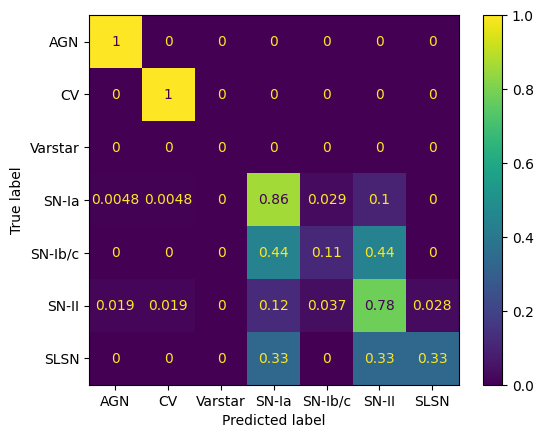

In [163]:
cf = confusion_matrix(df_classified['true'].to_numpy(), df_classified['l2_pred'].to_numpy(), labels=['AGN', 'CV', 'Varstar', 'SN-Ia', 'SN-Ib/c', 'SN-II', 'SLSN'], normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=['AGN', 'CV', 'Varstar', 'SN-Ia', 'SN-Ib/c', 'SN-II', 'SLSN'])
disp.plot()

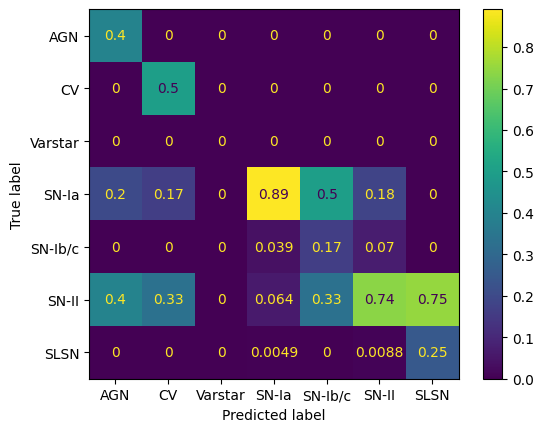

In [164]:
cf = confusion_matrix(df_classified['true'].to_numpy(), df_classified['l2_pred'].to_numpy(), labels=['AGN', 'CV', 'Varstar', 'SN-Ia', 'SN-Ib/c', 'SN-II', 'SLSN'], normalize='pred')

disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=['AGN', 'CV', 'Varstar', 'SN-Ia', 'SN-Ib/c', 'SN-II', 'SLSN'])
disp.plot()

In [165]:
report = classification_report(df_classified['true_1'].to_numpy(), df_classified['l1_pred'].to_numpy(), output_dict=True)

report1 = pd.DataFrame(report).transpose()
print(report1.to_latex(float_format=lambda x: f"{x:.2f}"))

\begin{tabular}{lrrrr}
\toprule
 & precision & recall & f1-score & support \\
\midrule
Persistent & 0.62 & 1.00 & 0.77 & 5.00 \\
Transient & 1.00 & 0.99 & 1.00 & 339.00 \\
accuracy & 0.99 & 0.99 & 0.99 & 0.99 \\
macro avg & 0.81 & 1.00 & 0.88 & 344.00 \\
weighted avg & 0.99 & 0.99 & 0.99 & 344.00 \\
\bottomrule
\end{tabular}



In [166]:
import os

os.makedirs("./Data", exist_ok=True)

from ztfquery import fritz

In [167]:

days = []
for row in tqdm(df_classified.itertuples(), total=len(df_classified)):
    id_ = row.objectId
    classification_date = row.timestamp
    label = row.true

    lc = fritz.download_lightcurve(id_)

    days.append(classification_date - lc.mjd.min())



100%|██████████| 344/344 [03:07<00:00,  1.84it/s]


In [168]:
df_classified['days'] = days

/var/folders/t6/gdw9ytlx48nd402t7_62k3r00000gn/T/ipykernel_29133/2640602016.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_classified['days'] = days


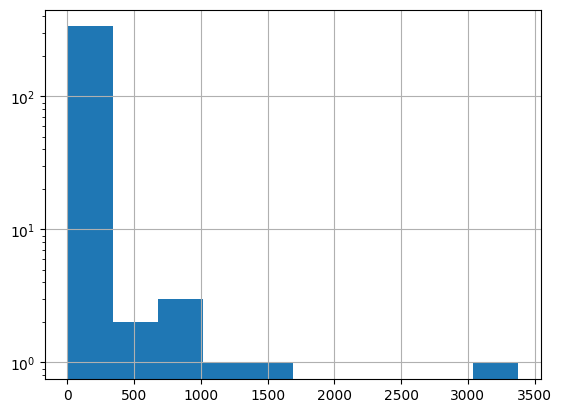

In [169]:
df_classified['days'].hist()
plt.yscale('log')